### Import Modules

In [7]:
from umap import UMAP
import pandas as pd
from ai_patterns_mining import Config
import seaborn as sns
import matplotlib.pyplot as plt

### Load Data

In [16]:
data = pd.read_csv('./embeddings_result/embeddings_call_graph_clusters_v1.csv')


In [25]:
data['cluster'] = data['code_file'].apply(lambda x: x.split('/')[-2])  # Extract repo name as cluster

In [28]:
cluster_mapper = {label: idx for idx, label in enumerate(data['cluster'].unique())}

In [39]:
cluster_mapper[list(cluster_mapper.keys())[1]]

1

In [41]:
data['cluster'] = data['cluster'].apply(lambda x: cluster_mapper[x])

In [42]:
data.head()

,code_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_759,dim_760,dim_761,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767,cluster
0,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.010473,-0.086456,0.020704,0.072811,-0.069658,0.079100,0.016109,-0.116357,0.035185,...,-0.024537,-0.067877,0.075597,0.099720,0.035907,0.233789,-0.317256,0.070238,0.092933,0
1,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.002774,-0.155825,-0.016958,0.109435,-0.134882,-0.026956,0.019212,-0.135563,0.029505,...,-0.018589,-0.053212,0.127422,0.065531,0.024898,0.390377,-0.205732,0.016368,0.122040,0
2,/root/AI-Pattern-Mining-Project/outputs/prompt...,-0.000473,-0.199095,-0.024379,0.095847,-0.138792,-0.012554,0.002148,-0.176035,0.042417,...,-0.024046,-0.045352,0.143503,0.057276,0.029717,0.420159,-0.237789,0.003915,0.154167,0
3,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.016031,-0.193469,0.001521,0.100525,-0.102650,-0.121538,0.017241,-0.197112,0.069094,...,0.019782,-0.054770,0.114624,0.046622,0.047399,0.395274,-0.168212,-0.044403,0.211058,0
4,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.003953,-0.221190,-0.005675,0.139310,-0.175301,-0.049305,0.008009,-0.185112,0.046989,...,-0.029435,-0.020810,0.141135,0.036710,0.048247,0.451174,-0.169562,-0.032311,0.211697,0


In [49]:
features = data[[col for col in data.columns if col.startswith('dim_')]].values

In [50]:
features

array([[ 0.01047305, -0.08645643,  0.02070366, ..., -0.31725639,
         0.07023837,  0.09293281],
       [ 0.00277441, -0.155825  , -0.01695829, ..., -0.20573248,
         0.01636776,  0.12203988],
       [-0.00047336, -0.19909501, -0.02437916, ..., -0.23778914,
         0.00391494,  0.15416691],
       ...,
       [ 0.04273874, -0.17358337, -0.00651733, ..., -0.15754959,
         0.00796394,  0.13114305],
       [ 0.02163135, -0.11157134, -0.02676811, ..., -0.23212434,
         0.01961858,  0.07739592],
       [ 0.04040015, -0.10137244, -0.0119012 , ..., -0.15349983,
         0.02869294,  0.06434871]], shape=(520, 768))

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


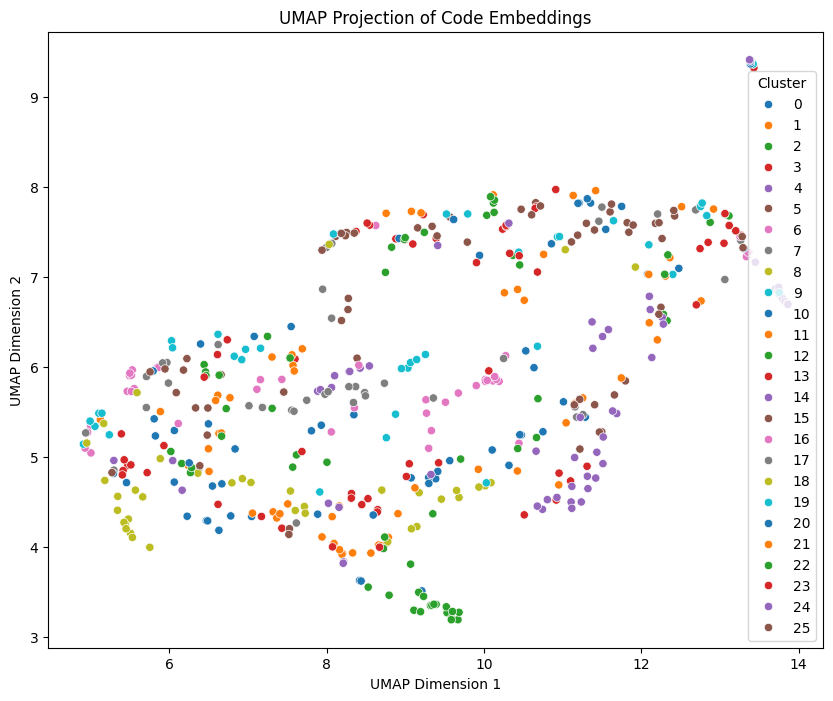

In [ ]:
umap_model = UMAP(n_neighbors=15, min_dist=0.01, n_components=2, random_state=42)

embeddings_2d = umap_model.fit_transform(features)
data['umap_x'] = embeddings_2d[:, 0]
data['umap_y'] = embeddings_2d[:, 1]

plt.figure(figsize=(10, 8))
sns.scatterplot(x='umap_x', y='umap_y', hue='cluster', data=data, palette='tab10', legend='full')
plt.title('UMAP Projection of Code Embeddings')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')
plt.legend(title='Cluster')
plt.show()

### Cluster

In [66]:
from sklearn.cluster import DBSCAN, KMeans,AgglomerativeClustering
from sklearn.metrics import silhouette_score,accuracy_score

In [65]:
agglomerative = AgglomerativeClustering(n_clusters=26)
data['agglomerative_cluster'] = agglomerative.fit_predict(features)
data

,code_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_764,dim_765,dim_766,dim_767,cluster,umap_x,umap_y,dbscan_cluster,kmeans_cluster,agglomerative_cluster
0,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.010473,-0.086456,0.020704,0.072811,-0.069658,0.079100,0.016109,-0.116357,0.035185,...,0.233789,-0.317256,0.070238,0.092933,0,12.477291,7.092978,-1,18,3
1,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.002774,-0.155825,-0.016958,0.109435,-0.134882,-0.026956,0.019212,-0.135563,0.029505,...,0.390377,-0.205732,0.016368,0.122040,0,10.317975,4.906140,-1,13,18
2,/root/AI-Pattern-Mining-Project/outputs/prompt...,-0.000473,-0.199095,-0.024379,0.095847,-0.138792,-0.012554,0.002148,-0.176035,0.042417,...,0.420159,-0.237789,0.003915,0.154167,0,9.074229,4.766252,-1,13,18
3,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.016031,-0.193469,0.001521,0.100525,-0.102650,-0.121538,0.017241,-0.197112,0.069094,...,0.395274,-0.168212,-0.044403,0.211058,0,9.210913,3.511287,-1,4,5
4,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.003953,-0.221190,-0.005675,0.139310,-0.175301,-0.049305,0.008009,-0.185112,0.046989,...,0.451174,-0.169562,-0.032311,0.211697,0,5.823646,5.232464,-1,7,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.030354,-0.168719,-0.008438,0.106609,-0.116861,-0.029594,0.011258,-0.144972,0.066828,...,0.378686,-0.115106,0.005070,0.141255,25,8.186790,7.481745,-1,22,12
516,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.023714,-0.143990,-0.018603,0.081253,-0.064636,0.014043,0.013744,-0.112111,0.050681,...,0.329030,-0.207322,0.011335,0.095837,25,11.191499,7.461597,-1,20,10
517,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.042739,-0.173583,-0.006517,0.116361,-0.058302,-0.029131,0.012620,-0.099026,0.031317,...,0.329106,-0.157550,0.007964,0.131143,25,10.606153,7.687538,-1,19,10
518,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.021631,-0.111571,-0.026768,0.112266,-0.096875,-0.053152,0.012660,-0.096677,0.034902,...,0.269077,-0.232124,0.019619,0.077396,25,11.896204,7.573841,-1,10,20


In [67]:
accuracy_score(data['cluster'],data['agglomerative_cluster'])

0.011538461538461539

In [68]:
accuracy_score(data['cluster'],data['kmeans_cluster'])

0.057692307692307696

In [69]:
accuracy_score(data['cluster'],data['dbscan_cluster'])

0.0

In [63]:
kmeans = KMeans(n_clusters=26, random_state=42)
data['kmeans_cluster'] = kmeans.fit_predict(features)
data

,code_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_763,dim_764,dim_765,dim_766,dim_767,cluster,umap_x,umap_y,dbscan_cluster,kmeans_cluster
0,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.010473,-0.086456,0.020704,0.072811,-0.069658,0.079100,0.016109,-0.116357,0.035185,...,0.035907,0.233789,-0.317256,0.070238,0.092933,0,12.477291,7.092978,-1,18
1,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.002774,-0.155825,-0.016958,0.109435,-0.134882,-0.026956,0.019212,-0.135563,0.029505,...,0.024898,0.390377,-0.205732,0.016368,0.122040,0,10.317975,4.906140,-1,13
2,/root/AI-Pattern-Mining-Project/outputs/prompt...,-0.000473,-0.199095,-0.024379,0.095847,-0.138792,-0.012554,0.002148,-0.176035,0.042417,...,0.029717,0.420159,-0.237789,0.003915,0.154167,0,9.074229,4.766252,-1,13
3,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.016031,-0.193469,0.001521,0.100525,-0.102650,-0.121538,0.017241,-0.197112,0.069094,...,0.047399,0.395274,-0.168212,-0.044403,0.211058,0,9.210913,3.511287,-1,4
4,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.003953,-0.221190,-0.005675,0.139310,-0.175301,-0.049305,0.008009,-0.185112,0.046989,...,0.048247,0.451174,-0.169562,-0.032311,0.211697,0,5.823646,5.232464,-1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.030354,-0.168719,-0.008438,0.106609,-0.116861,-0.029594,0.011258,-0.144972,0.066828,...,0.040785,0.378686,-0.115106,0.005070,0.141255,25,8.186790,7.481745,-1,22
516,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.023714,-0.143990,-0.018603,0.081253,-0.064636,0.014043,0.013744,-0.112111,0.050681,...,0.020405,0.329030,-0.207322,0.011335,0.095837,25,11.191499,7.461597,-1,20
517,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.042739,-0.173583,-0.006517,0.116361,-0.058302,-0.029131,0.012620,-0.099026,0.031317,...,0.007502,0.329106,-0.157550,0.007964,0.131143,25,10.606153,7.687538,-1,19
518,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.021631,-0.111571,-0.026768,0.112266,-0.096875,-0.053152,0.012660,-0.096677,0.034902,...,0.001866,0.269077,-0.232124,0.019619,0.077396,25,11.896204,7.573841,-1,10


In [61]:
umap_model = UMAP(n_neighbors=20, min_dist=0.01, n_components=450, random_state=42)
data_umap_450d = umap_model.fit_transform(features)
dbscan = DBSCAN(eps=0.1, min_samples=20)
data['dbscan_cluster'] = dbscan.fit_predict(data_umap_450d)
print(data['dbscan_cluster'].value_counts())

/home/hasinthaka/Documents/Projects/AI/Pattern Mining/pipeline/.venv/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


dbscan_cluster
-1    520
Name: count, dtype: int64


In [56]:
data

,code_file,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_762,dim_763,dim_764,dim_765,dim_766,dim_767,cluster,umap_x,umap_y,dbscan_cluster
0,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.010473,-0.086456,0.020704,0.072811,-0.069658,0.079100,0.016109,-0.116357,0.035185,...,0.099720,0.035907,0.233789,-0.317256,0.070238,0.092933,0,12.477291,7.092978,-1
1,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.002774,-0.155825,-0.016958,0.109435,-0.134882,-0.026956,0.019212,-0.135563,0.029505,...,0.065531,0.024898,0.390377,-0.205732,0.016368,0.122040,0,10.317975,4.906140,-1
2,/root/AI-Pattern-Mining-Project/outputs/prompt...,-0.000473,-0.199095,-0.024379,0.095847,-0.138792,-0.012554,0.002148,-0.176035,0.042417,...,0.057276,0.029717,0.420159,-0.237789,0.003915,0.154167,0,9.074229,4.766252,-1
3,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.016031,-0.193469,0.001521,0.100525,-0.102650,-0.121538,0.017241,-0.197112,0.069094,...,0.046622,0.047399,0.395274,-0.168212,-0.044403,0.211058,0,9.210913,3.511287,-1
4,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.003953,-0.221190,-0.005675,0.139310,-0.175301,-0.049305,0.008009,-0.185112,0.046989,...,0.036710,0.048247,0.451174,-0.169562,-0.032311,0.211697,0,5.823646,5.232464,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
515,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.030354,-0.168719,-0.008438,0.106609,-0.116861,-0.029594,0.011258,-0.144972,0.066828,...,0.011549,0.040785,0.378686,-0.115106,0.005070,0.141255,25,8.186790,7.481745,-1
516,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.023714,-0.143990,-0.018603,0.081253,-0.064636,0.014043,0.013744,-0.112111,0.050681,...,0.024829,0.020405,0.329030,-0.207322,0.011335,0.095837,25,11.191499,7.461597,-1
517,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.042739,-0.173583,-0.006517,0.116361,-0.058302,-0.029131,0.012620,-0.099026,0.031317,...,0.036649,0.007502,0.329106,-0.157550,0.007964,0.131143,25,10.606153,7.687538,-1
518,/root/AI-Pattern-Mining-Project/outputs/prompt...,0.021631,-0.111571,-0.026768,0.112266,-0.096875,-0.053152,0.012660,-0.096677,0.034902,...,0.055622,0.001866,0.269077,-0.232124,0.019619,0.077396,25,11.896204,7.573841,-1
